In [22]:
# Script: Extração de voltas (laps) + clima (FastF1) 2022–2024
# -*- coding: utf-8 -*-

from pathlib import Path
import pandas as pd
import numpy as np
import fastf1

# =========================
# Parâmetros gerais
# =========================
YEARS = [2022, 2023, 2024]
SKIP_IF_SAVED = True

# =========================
# Estrutura de pastas (sempre usar notebooks/fastf1_cache)
# =========================
CWD = Path.cwd().resolve()
NB_DIR = CWD if CWD.name.lower() == "notebooks" else CWD / "notebooks"

DATA_DIR = NB_DIR / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)
INTERIM = DATA_DIR / "interim"
INTERIM.mkdir(parents=True, exist_ok=True)

CACHE_DIR = NB_DIR / "fastf1_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
fastf1.Cache.enable_cache(str(CACHE_DIR))

print(f"Cache ativo em: {CACHE_DIR}")
print(f"Saídas em:      {INTERIM}")

# =========================
# Circuitos-alvo
# =========================
TARGETS = {
    "Bahrein":     {"location": ["sakhir", "bahrain"],            "event_sub": ["bahrain"]},
    "Jeddah":      {"location": ["jeddah"],                       "event_sub": ["saudi"]},
    "Australia":   {"location": ["melbourne", "australia"],       "event_sub": ["australian"]},
    "Baku":        {"location": ["baku"],                         "event_sub": ["azerbaijan"]},
    "Miami":       {"location": ["miami"],                        "event_sub": ["miami"]},
    "Monza":       {"location": ["monza"],                        "event_sub": ["italian"]},
    "Singapura":   {"location": ["singapore"],                    "event_sub": ["singapore"]},
    "Suzuka":      {"location": ["suzuka"],                       "event_sub": ["japan"]},
    "COTA":        {"location": ["austin"],                       "event_sub": ["united states"]},
    "Mexico":      {"location": ["mexico city"],                  "event_sub": ["mexico"]},
    "Brasil":      {"location": ["são paulo", "sao paulo"],       "event_sub": ["sao paulo", "brazil"]},
    "Abu Dhabi":   {"location": ["abu dhabi", "yas marina"],      "event_sub": ["abu dhabi"]},
    "Silverstone": {"location": ["silverstone"],                  "event_sub": ["british", "great britain"]},
    "Bélgica":     {"location": ["spa-francorchamps", "spa"],     "event_sub": ["belgian"]},
    "Hungria":     {"location": ["hungaroring", "budapest"],      "event_sub": ["hungarian"]},
    "Mônaco":      {"location": ["monaco"],                       "event_sub": ["monaco"]},
}

# =========================
# Auxiliares reutilizáveis
# =========================
WEATHER_COLS = ["AirTemp","TrackTemp","Humidity","Pressure","WindSpeed","WindDirection","Rainfall","WeatherTime"]

def to_seconds(td):
    """Converte um pandas.Timedelta (ou NaT) para float em segundos."""
    return np.nan if pd.isna(td) else td.total_seconds()

def ensure_tyre_age(df: pd.DataFrame) -> pd.DataFrame:
    """Garante a coluna TyreLife; se ausente ou toda NaN, reconstrói por (Driver, Stint)."""
    df = df.copy()
    if "TyreLife" not in df.columns or df["TyreLife"].isna().all():
        if {"Driver", "Stint", "LapNumber"}.issubset(df.columns):
            df = df.sort_values(["Driver", "Stint", "LapNumber"])
            df["TyreLife"] = df.groupby(["Driver", "Stint"]).cumcount() + 1
        else:
            df["TyreLife"] = np.nan
    return df

def needs_weather_enrichment(df: pd.DataFrame) -> bool:
    """True se faltar alguma coluna de clima OU se todas as colunas de clima forem 100% nulas."""
    missing = [c for c in WEATHER_COLS if c not in df.columns]
    if missing:
        return True
    return all(df[c].isna().all() for c in WEATHER_COLS if c in df.columns)

def build_calendar(years: list[int]) -> pd.DataFrame:
    all_events = []
    for y in years:
        cal = fastf1.get_event_schedule(y, include_testing=False).copy()
        keep_cols = [c for c in ["RoundNumber","EventName","OfficialEventName","EventDate","Location","EventFormat"] if c in cal.columns]
        cal = cal[keep_cols]
        cal["Year"] = y
        cal["loc_lc"] = cal["Location"].fillna("").str.lower()
        cal["ename_lc"] = cal["EventName"].fillna("").str.lower()
        all_events.append(cal)
    return pd.concat(all_events, ignore_index=True)

def row_matches_target(row, target) -> bool:
    loc = row["loc_lc"]
    enm = row["ename_lc"]
    if any(sub in loc for sub in target["location"]):
        return True
    if any(sub in enm for sub in target["event_sub"]):
        return True
    return False

def _prepare_weather_df(session) -> pd.DataFrame | None:
    """Seleciona e ordena colunas de clima (ou retorna None)."""
    wd = getattr(session, "weather_data", None)
    if wd is None or wd.empty:
        return None
    wd = wd.copy()
    keep_weather = [c for c in ["Time","AirTemp","TrackTemp","Humidity","Pressure","WindSpeed","WindDirection","Rainfall"] if c in wd.columns]
    wd = wd[keep_weather].dropna(subset=["Time"]).sort_values("Time")
    # Assegura tipo Timedelta
    wd["Time"] = pd.to_timedelta(wd["Time"])
    return wd

def _build_mid_key(laps: pd.DataFrame) -> pd.Series:
    """
    Constrói uma chave temporal robusta:
    1) LapStartTime + LapTime/2
    2) fallback: LapStartTime
    3) fallback: Time
    """
    key = pd.Series(pd.NaT, index=laps.index, dtype="timedelta64[ns]")
    if {"LapStartTime","LapTime"}.issubset(laps.columns):
        mid = pd.to_timedelta(laps["LapStartTime"]) + (pd.to_timedelta(laps["LapTime"]).fillna(pd.Timedelta(0)) / 2)
        key = mid
    elif "LapStartTime" in laps.columns:
        key = pd.to_timedelta(laps["LapStartTime"])
    elif "Time" in laps.columns:
        key = pd.to_timedelta(laps["Time"])
    return key

def _safe_weather_merge(laps_in: pd.DataFrame, weather: pd.DataFrame | None) -> pd.DataFrame:
    """Faz merge_asof com chave segura; se não houver clima, devolve com colunas preenchidas/NaN."""
    laps = laps_in.copy()

    if weather is None or weather.empty:
        for c in WEATHER_COLS:
            if c not in laps.columns:
                laps[c] = pd.NA
        return laps

    # Chave temporal robusta
    laps["LapMidKey"] = _build_mid_key(laps)

    # Remove linhas sem chave (evita erro de merge por NaT)
    before = len(laps)
    laps = laps.dropna(subset=["LapMidKey"])
    dropped = before - len(laps)
    if dropped > 0:
        print(f"[INFO] Removidas {dropped} voltas sem timestamp válido para merge de clima.")

    # Ordena para o merge_asof
    left = laps.sort_values("LapMidKey")
    right = weather.sort_values("Time")

    merged = pd.merge_asof(
        left=left,
        right=right,
        left_on="LapMidKey",
        right_on="Time",
        direction="backward",
        allow_exact_matches=True
    ).rename(columns={"Time": "WeatherTime"})

    merged.drop(columns=["LapMidKey"], inplace=True, errors="ignore")

    # Garante presença de todas as colunas de clima
    for c in WEATHER_COLS:
        if c not in merged.columns:
            merged[c] = pd.NA

    return merged

def extract_event_race_laps(year: int, round_number: int | None, event_name: str | None) -> pd.DataFrame:
    """
    Extrai TODAS as voltas da corrida (R) e agrega clima no MESMO PASSO, de forma robusta.
    """
    # Obter sessão
    ses = fastf1.get_session(int(year), int(round_number), 'R') if pd.notna(round_number) else fastf1.get_session(int(year), str(event_name), 'R')
    # Carrega garantindo clima
    ses.load(telemetry=False, weather=True)

    # Base de voltas
    laps = ses.laps.copy().reset_index(drop=True)

    # Garantias de colunas de pit
    for c in ["PitInTime", "PitOutTime"]:
        if c not in laps.columns:
            laps[c] = pd.NaT

    # Flags de pit
    laps["IsPitInLap"]   = laps["PitInTime"].notna().astype(int)
    laps["IsPitOutLap"]  = laps["PitOutTime"].notna().astype(int)
    laps["IsInOrOutLap"] = (laps["IsPitInLap"] | laps["IsPitOutLap"]).astype(int)

    # Tempos em segundos (mantém os timedelta originais)
    for c in ["LapTime", "Sector1Time", "Sector2Time", "Sector3Time"]:
        if c in laps.columns:
            laps[c + "Sec"] = laps[c].apply(to_seconds)

    # Tyre life
    laps = ensure_tyre_age(laps)

    # Metadados
    laps["Year"] = int(year)
    laps["RoundNumber"] = int(round_number) if pd.notna(round_number) else np.nan
    laps["EventName"] = ses.event.EventName if hasattr(ses, "event") else (event_name or "")
    laps["SessionName"] = "Race"

    # Merge clima (robusto)
    weather = _prepare_weather_df(ses)
    laps = _safe_weather_merge(laps, weather)

    # Ordena “bonito”
    sort_cols = [c for c in ["Driver","LapNumber"] if c in laps.columns]
    if sort_cols:
        laps = laps.sort_values(sort_cols).reset_index(drop=True)

    return laps

def enrich_weather_if_needed(df_in: pd.DataFrame) -> pd.DataFrame:
    """Fallback: se um dataset existente não tiver clima, reabre por (Year, EventName) e agrega clima por grupo."""
    if not needs_weather_enrichment(df_in):
        return df_in

    req = {"Year","EventName"}
    df = df_in.copy()
    for c in WEATHER_COLS:
        if c not in df.columns:
            df[c] = pd.NA

    if not req.issubset(df.columns):
        print("[AVISO] Não consigo enriquecer clima (faltam Year/EventName). Devolvendo com colunas de clima vazias.")
        return df

    print("[INFO] Enriquecendo dataset existente com clima por (Year, EventName)…")
    out_chunks = []
    for (y, ename), g in df.groupby(["Year","EventName"]):
        y = int(y) if pd.notna(y) else None
        if y is None or not ename:
            out_chunks.append(g)
            continue
        try:
            # round pode não estar confiável em datasets antigos -> usa EventName
            fresh = extract_event_race_laps(y, np.nan, ename)
            # Mantém apenas colunas de clima + chave p/ merge
            keep = ["AirTemp","TrackTemp","Humidity","Pressure","WindSpeed","WindDirection","Rainfall","WeatherTime","Driver","LapNumber"]
            join_keys = [k for k in ["Driver","LapNumber"] if k in g.columns and k in fresh.columns]
            if not join_keys:
                out_chunks.append(g)  # sem chaves seguras, mantém g
                continue
            gg = g.drop(columns=[c for c in WEATHER_COLS if c in g.columns], errors="ignore")
            merged = gg.merge(fresh[join_keys + [c for c in keep if c in fresh.columns]],
                              on=join_keys, how="left", validate="m:1")
            out_chunks.append(merged)
        except Exception as e:
            print(f"[AVISO] Falha ao reabrir/enriquecer {y}-{ename}: {e}. Mantendo grupo original.")
            out_chunks.append(g)
    print("[INFO] Enriquecimento concluído.")
    return pd.concat(out_chunks, ignore_index=True)

# =========================
# Calendário consolidado
# =========================
events_df = build_calendar(YEARS)

# =========================
# Loop principal por circuito (extração já com clima)
# =========================
all_circuits_laps = []

for circuito, matchers in TARGETS.items():
    safe_circuit = circuito.lower().replace(" ", "_")
    out_csv  = INTERIM / f"{safe_circuit}_2022-2024_all_laps.csv"
    out_parq = INTERIM / f"{safe_circuit}_2022-2024_all_laps.parquet"

    # (0) Reaproveitar existente se permitido
    if SKIP_IF_SAVED and (out_parq.exists() or out_csv.exists()):
        try:
            if out_parq.exists():
                laps_circuito = pd.read_parquet(out_parq)
                print(f"[PULADO] {circuito}: Parquet existente.")
            else:
                laps_circuito = pd.read_csv(out_csv)
                print(f"[PULADO] {circuito}: CSV existente.")
            # Se faltar clima, enriquece (seguro)
            if needs_weather_enrichment(laps_circuito):
                print(f"[INFO] {circuito}: dataset existente sem clima — enriquecendo…")
                laps_circuito = enrich_weather_if_needed(laps_circuito)
                laps_circuito.to_parquet(out_parq, index=False)
                laps_circuito.to_csv(out_csv, index=False, encoding="utf-8")
                print(f"[SALVO] {circuito}: arquivos atualizados com clima.")
            all_circuits_laps.append(laps_circuito)
            continue
        except Exception as e:
            print(f"[AVISO] Falha ao ler/enriquecer saída existente de '{circuito}' ({e}). Reextraindo…")

    # (1) Encontrar eventos do circuito
    mask = events_df.apply(lambda r: row_matches_target(r, matchers), axis=1)
    cal_hits = events_df[mask].copy().sort_values(["Year","RoundNumber","EventDate"])
    if cal_hits.empty:
        print(f"[AVISO] Nenhum evento encontrado para '{circuito}' em {YEARS}.")
        continue

    print(f"\n=== {circuito}: {len(cal_hits)} evento(s) 2022–2024 ===")
    per_circuit_laps, errors = [], []

    # (2) Extrair por evento (ano), já com clima
    for _, ev in cal_hits.iterrows():
        y = int(ev["Year"])
        rnd = ev["RoundNumber"] if "RoundNumber" in ev and pd.notna(ev["RoundNumber"]) else None
        ename = ev["EventName"]
        try:
            df_laps = extract_event_race_laps(y, rnd, ename)
            # Metadados adicionais
            df_laps["Circuito"] = circuito
            df_laps["EventDate"] = pd.to_datetime(ev["EventDate"]).date() if pd.notna(ev["EventDate"]) else pd.NaT
            df_laps["Location"] = ev["Location"]
            df_laps["OfficialEventName"] = ev.get("OfficialEventName", np.nan)
            per_circuit_laps.append(df_laps)
            print(f"[OK] {circuito} {y} (Round {rnd if rnd is not None else 'n/a'}): {len(df_laps)} voltas (com clima).")
        except Exception as e:
            print(f"[ERRO] {circuito} {y} (Round {rnd if rnd is not None else 'n/a'}): {e}")
            errors.append((circuito, y, str(e)))

    # (3) Consolidar e salvar
    if per_circuit_laps:
        laps_circuito = pd.concat(per_circuit_laps, ignore_index=True)
        sort_cols = [c for c in ["Year","Driver","LapNumber"] if c in laps_circuito.columns]
        if sort_cols:
            laps_circuito = laps_circuito.sort_values(sort_cols).reset_index(drop=True)
        laps_circuito.to_csv(out_csv, index=False, encoding="utf-8")
        laps_circuito.to_parquet(out_parq, index=False)
        print(f"[SALVO] {circuito}:\n        CSV:     {out_csv}\n        Parquet: {out_parq}")
        all_circuits_laps.append(laps_circuito)
    else:
        print(f"[AVISO] Nenhuma volta consolidada para '{circuito}'. Erros: {len(errors)}")

# =========================
# Dataset mestre
# =========================
if all_circuits_laps:
    master = pd.concat(all_circuits_laps, ignore_index=True)
    preview_cols = [c for c in ["Circuito","Year","EventName","Driver","LapNumber","LapTime","TrackTemp","AirTemp","Compound","PitInTime","PitOutTime"] if c in master.columns]
    print("\n=== AMOSTRA (dataset mestre) ===")
    print((master[preview_cols] if preview_cols else master).head(12).to_string(index=False))

    master_csv  = INTERIM / "ALLCIRCUITS_2022-2024_all_laps.csv"
    master_parq = INTERIM / "ALLCIRCUITS_2022-2024_all_laps.parquet"
    master.to_csv(master_csv, index=False, encoding="utf-8")
    master.to_parquet(master_parq, index=False)
    print(f"\n[SALVO] Dataset mestre:\n        CSV:     {master_csv}\n        Parquet: {master_parq}")
else:
    raise RuntimeError("Nenhuma volta foi extraída para os circuitos solicitados.")


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data


Cache ativo em: C:\Users\pedro\iCloudDrive\Desktop\Eng. Elétrica UNESP Bauru 2020\TG\TG2\f1-tyre-strategy-simulator\notebooks\fastf1_cache
Saídas em:      C:\Users\pedro\iCloudDrive\Desktop\Eng. Elétrica UNESP Bauru 2020\TG\TG2\f1-tyre-strategy-simulator\notebooks\data\interim

=== Bahrein: 3 evento(s) 2022–2024 ===


req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 16 completed the race distance 00:00.050000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['16', '55', '44', '63', '20', '77', '31', '22', '14', '24', '47', '18', '23', '3', '4', '6', '27', '11', '1', '10']
core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing

[OK] Bahrein 2022 (Round 1): 1125 voltas (com clima).


req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '14', '55', '44', '18', '63', '77', '10', '23', '22', '2', '20', '21', '27', '24', '4', '31', '16', '81']
core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


...

[OK] Mônaco 2022 (Round 7): 1179 voltas (com clima).


req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '14', '31', '44', '63', '16', '10', '55', '4', '81', '77', '21', '24', '23', '22', '11', '27', '2', '20', '18']
core           INFO 	Loading data for Monaco Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


[OK] Mônaco 2023 (Round 6): 1515 voltas (com clima).


req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '81', '55', '4', '63', '1', '44', '22', '23', '10', '14', '3', '77', '18', '2', '24', '31', '11', '27', '20']


[OK] Mônaco 2024 (Round 8): 1237 voltas (com clima).
[SALVO] Mônaco:
        CSV:     C:\Users\pedro\iCloudDrive\Desktop\Eng. Elétrica UNESP Bauru 2020\TG\TG2\f1-tyre-strategy-simulator\notebooks\data\interim\mônaco_2022-2024_all_laps.csv
        Parquet: C:\Users\pedro\iCloudDrive\Desktop\Eng. Elétrica UNESP Bauru 2020\TG\TG2\f1-tyre-strategy-simulator\notebooks\data\interim\mônaco_2022-2024_all_laps.parquet

=== AMOSTRA (dataset mestre) ===
Circuito  Year          EventName Driver  LapNumber                LapTime  TrackTemp  AirTemp Compound PitInTime PitOutTime
 Bahrein  2022 Bahrain Grand Prix    ALB        1.0 0 days 00:01:47.636000       29.1     23.9     SOFT       NaT        NaT
 Bahrein  2022 Bahrain Grand Prix    ALB        2.0 0 days 00:01:40.548000       29.0     23.8     SOFT       NaT        NaT
 Bahrein  2022 Bahrain Grand Prix    ALB        3.0 0 days 00:01:40.664000       29.0     23.8     SOFT       NaT        NaT
 Bahrein  2022 Bahrain Grand Prix    ALB        4.0 0

In [23]:
# === CÉLULA: Pós-processamento do DATASET MESTRE ===
from pathlib import Path
import pandas as pd

# Caminhos (usa o mesmo layout do script anterior; ajusta se necessário)
NB_DIR = Path.cwd().resolve() if Path.cwd().name.lower() == "notebooks" else Path.cwd().resolve() / "notebooks"
INTERIM = NB_DIR / "data" / "interim"
master_parq = INTERIM / "ALLCIRCUITS_2022-2024_all_laps.parquet"
master_csv  = INTERIM / "ALLCIRCUITS_2022-2024_all_laps.csv"

# --- Carrega o dataset mestre (prefere csv) ---
if master_csv.exists():
    df = pd.read_csv(master_csv)
    print(f"[LOAD] {master_csv}")
elif master_parq.exists():
    df = pd.read_parquet(master_parq)
    print(f"[LOAD] {master_parq}")
else:
    raise FileNotFoundError("Gere primeiro o dataset mestre (ALLCIRCUITS_2022-2024_all_laps.*).")

# --- Cria/normaliza LapTimeSec (segundos) ---
if "LapTimeSec" not in df.columns:
    if "LapTime" in df.columns:
        if pd.api.types.is_timedelta64_dtype(df["LapTime"]):
            df["LapTimeSec"] = df["LapTime"].dt.total_seconds()     # converte timedelta -> segundos
        else:
            df["LapTimeSec"] = pd.to_numeric(df["LapTime"], errors="coerce")  # tenta converter numérico
    else:
        df["LapTimeSec"] = pd.NA

# --- Padroniza Compound e TrackStatus para evitar perdas no filtro ---
if "Compound" in df.columns:
    df["Compound"] = df["Compound"].astype(str).str.upper()
if "TrackStatus" in df.columns:
    df["_TrackStatusStr"] = df["TrackStatus"].astype(str).str.strip()

# ========== FILTROS (ORDEM OTIMIZADA) ==========

# 0) Remover voltas marcadas como deletadas (mantém apenas Deleted == False)
if "Deleted" in df.columns:
    before = len(df)
    df = df[df["Deleted"] == False]
    after = len(df)
    print(f"Removidas {before - after} voltas com Deleted diferente de False. Restantes: {after}")
else:
    print("Coluna 'Deleted' não encontrada no DataFrame.")

# 1) Remover voltas imprecisas (IsAccurate == False)
if "IsAccurate" in df.columns:
    before = len(df)
    df = df[df["IsAccurate"]]
    after = len(df)
    print(f"Removidas {before - after} voltas com IsAccurate = False. Restantes: {after}")
else:
    print("Coluna 'IsAccurate' não encontrada no DataFrame.")

# 2) Remover linhas com tempos/setores críticos ausentes (nulos)

if "Sector1SessionTime" in df.columns:
    before = len(df)
    df = df.dropna(subset=["Sector1SessionTime"])
    after = len(df)
    print(f"Removidas {before - after} voltas com Sector1SessionTime nulo. Restantes: {after}")
else:
    print("Coluna 'Sector1SessionTime' não encontrada no DataFrame.")

if "SpeedFL" in df.columns:
    before = len(df)
    df = df.dropna(subset=["SpeedFL"])
    after = len(df)
    print(f"Removidas {before - after} voltas com SpeedFL nulo. Restantes: {after}")
else:
    print("Coluna 'SpeedFL' não encontrada no DataFrame.")

if "TyreLife" in df.columns:
    before = len(df)
    df = df.dropna(subset=["TyreLife"])
    after = len(df)
    print(f"Removidas {before - after} voltas sem TyreLife. Restantes: {after}")
else:
    print("Coluna 'TyreLife' não encontrada no DataFrame.")

# 4) Apenas compostos secos (SOFT/MEDIUM/HARD)
if "Compound" in df.columns:
    before = len(df)
    # se necessário, padronize: df["Compound"] = df["Compound"].astype(str).str.upper()
    df = df[df["Compound"].isin(["SOFT", "MEDIUM", "HARD"])]
    after = len(df)
    print(f"Removidas {before - after} voltas com pneus intermediários/molhados. Restantes: {after}")

# 5) Apenas pista verde (TrackStatus == 1)
if "TrackStatus" in df.columns:
    before = len(df)
    # auxiliar robusto para comparar com '1'
    _ts = df["TrackStatus"].astype(str).str.strip()
    mask_green = (_ts == "1") | (pd.to_numeric(df["TrackStatus"], errors="coerce") == 1)
    df = df[mask_green]
    after = len(df)
    print(f"Removidas {before - after} voltas com bandeiras/SC/VSC. Restantes: {after}")

# 6) ≤ 120% da mediana de LapTimeSec específica de cada evento (Year + EventName)
if {"LapTimeSec","Year","EventName"} <= set(df.columns):
    before_total = len(df)

    def _filter_event(g):
        med = pd.to_numeric(g["LapTimeSec"], errors="coerce").median(skipna=True)
        if pd.notna(med):
            lim = 1.2 * med
            return g[pd.to_numeric(g["LapTimeSec"], errors="coerce") <= lim]
        return g

    df = df.groupby(["Year", "EventName"], group_keys=False).apply(_filter_event)
    after_total = len(df)
    print(f"Filtradas {before_total - after_total} voltas > 120% da mediana por evento. Restantes: {after_total}")
else:
    print("Aviso: faltam colunas para o filtro de 120% por evento (LapTimeSec/Year/EventName).")


# --- Inspeção rápida ---
print("\n=== INFO PÓS-FILTRO ===")
df.info()
display(df.head())

# --- Salva dataset filtrado ---
out_parq = INTERIM / "ALLCIRCUITS_2022-2024_all_laps_FILTERED.parquet"
out_csv  = INTERIM / "ALLCIRCUITS_2022-2024_all_laps_FILTERED.csv"
df.to_parquet(out_parq, index=False)
df.to_csv(out_csv, index=False, encoding="utf-8")
print(f"\n[SALVO] Parquet: {out_parq}")
print(f"[SALVO] CSV:     {out_csv}")


C:\Users\pedro\AppData\Local\Temp\ipykernel_9588\2668396843.py:13: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(master_csv)


[LOAD] C:\Users\pedro\iCloudDrive\Desktop\Eng. Elétrica UNESP Bauru 2020\TG\TG2\f1-tyre-strategy-simulator\notebooks\data\interim\ALLCIRCUITS_2022-2024_all_laps.csv
Removidas 593 voltas com Deleted diferente de False. Restantes: 49870
Removidas 6668 voltas com IsAccurate = False. Restantes: 43202
Removidas 97 voltas com Sector1SessionTime nulo. Restantes: 43105
Removidas 3 voltas com SpeedFL nulo. Restantes: 43102
Removidas 87 voltas sem TyreLife. Restantes: 43015
Removidas 2609 voltas com pneus intermediários/molhados. Restantes: 40406
Removidas 1070 voltas com bandeiras/SC/VSC. Restantes: 39336
Filtradas 73 voltas > 120% da mediana por evento. Restantes: 39263

=== INFO PÓS-FILTRO ===
<class 'pandas.core.frame.DataFrame'>
Index: 39263 entries, 34038 to 26657
Data columns (total 56 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Time_x              39263 non-null  object 
 1   Driver              39263 non-null  object 


C:\Users\pedro\AppData\Local\Temp\ipykernel_9588\2668396843.py:112: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["Year", "EventName"], group_keys=False).apply(_filter_event)


,Time_x,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,Pressure,WindSpeed,WindDirection,Rainfall,WeatherTime,Circuito,EventDate,Location,OfficialEventName,_TrackStatusStr
34038,0 days 01:05:25.360000,ALB,23,0 days 00:01:33.227000,2.0,1.0,NaN,NaN,0 days 00:00:18.788000,0 days 00:00:39.586000,...,1013.5,2.7,319,False,NaN,Abu Dhabi,2022-11-20,Yas Island,FORMULA 1 ETIHAD AIRWAYS ABU DHABI GRAND PRIX ...,1
34039,0 days 01:06:57.716000,ALB,23,0 days 00:01:32.356000,3.0,1.0,NaN,NaN,0 days 00:00:18.723000,0 days 00:00:38.407000,...,1013.4,3.2,290,False,NaN,Abu Dhabi,2022-11-20,Yas Island,FORMULA 1 ETIHAD AIRWAYS ABU DHABI GRAND PRIX ...,1
34040,0 days 01:08:30.853000,ALB,23,0 days 00:01:33.137000,4.0,1.0,NaN,NaN,0 days 00:00:18.687000,0 days 00:00:38.424000,...,1013.5,2.5,334,False,NaN,Abu Dhabi,2022-11-20,Yas Island,FORMULA 1 ETIHAD AIRWAYS ABU DHABI GRAND PRIX ...,1
34041,0 days 01:10:03.505000,ALB,23,0 days 00:01:32.652000,5.0,1.0,NaN,NaN,0 days 00:00:18.785000,0 days 00:00:38.870000,...,1013.5,3.5,302,False,NaN,Abu Dhabi,2022-11-20,Yas Island,FORMULA 1 ETIHAD AIRWAYS ABU DHABI GRAND PRIX ...,1
34042,0 days 01:11:35.807000,ALB,23,0 days 00:01:32.302000,6.0,1.0,NaN,NaN,0 days 00:00:18.718000,0 days 00:00:38.967000,...,1013.5,3.9,312,False,NaN,Abu Dhabi,2022-11-20,Yas Island,FORMULA 1 ETIHAD AIRWAYS ABU DHABI GRAND PRIX ...,1



[SALVO] Parquet: C:\Users\pedro\iCloudDrive\Desktop\Eng. Elétrica UNESP Bauru 2020\TG\TG2\f1-tyre-strategy-simulator\notebooks\data\interim\ALLCIRCUITS_2022-2024_all_laps_FILTERED.parquet
[SALVO] CSV:     C:\Users\pedro\iCloudDrive\Desktop\Eng. Elétrica UNESP Bauru 2020\TG\TG2\f1-tyre-strategy-simulator\notebooks\data\interim\ALLCIRCUITS_2022-2024_all_laps_FILTERED.csv


In [24]:
# === CÉLULA: Resumo estatístico e informativo do DataFrame final ===

print("\n=== RESUMO GERAL ===")
print(f"Total de linhas: {len(df)}")
print(f"Total de colunas: {len(df.columns)}")

# --- Visão geral do DataFrame ---
print("\n=== INFO ===")
df.info()

# --- Estatísticas descritivas para colunas numéricas ---
print("\n=== DESCRIBE (Numéricas) ===")
display(df.describe().T)  # .T para facilitar leitura (variáveis em linhas)

# --- Estatísticas descritivas também para colunas de texto/categóricas ---
print("\n=== DESCRIBE (Categóricas) ===")
display(df.describe(include='object').T)

# --- Frequência de valores para colunas não numéricas ---
print("\n=== FREQUÊNCIA DE VALORES (TOP 5) ===")
for col in df.columns:
    if df[col].dtype == 'object' or df[col].dtype.name == 'category' or df[col].dtype == 'bool':
        print(f"\nColuna: {col}")
        print(df[col].value_counts(dropna=False).head(5))



=== RESUMO GERAL ===
Total de linhas: 39263
Total de colunas: 56

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
Index: 39263 entries, 34038 to 26657
Data columns (total 56 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Time_x              39263 non-null  object 
 1   Driver              39263 non-null  object 
 2   DriverNumber        39263 non-null  int64  
 3   LapTime             39263 non-null  object 
 4   LapNumber           39263 non-null  float64
 5   Stint               39263 non-null  float64
 6   PitOutTime          0 non-null      object 
 7   PitInTime           0 non-null      object 
 8   Sector1Time         39263 non-null  object 
 9   Sector2Time         39263 non-null  object 
 10  Sector3Time         39263 non-null  object 
 11  Sector1SessionTime  39263 non-null  object 
 12  Sector2SessionTime  39263 non-null  object 
 13  Sector3SessionTime  39263 non-null  object 
 14  SpeedI1             326

,count,mean,std,min,25%,50%,75%,max
DriverNumber,39263.0,27.380689,23.021719,1.000,11.0000,21.000,44.0000,81.000
LapNumber,39263.0,30.338487,17.170146,2.000,16.0000,30.000,44.0000,78.000
Stint,39263.0,2.034867,0.887074,1.000,1.0000,2.000,3.0000,6.000
SpeedI1,32607.0,262.284939,42.561256,96.000,215.0000,278.000,292.0000,355.000
SpeedI2,39263.0,248.983496,46.904200,139.000,201.0000,253.000,294.0000,343.000
SpeedFL,39263.0,261.483967,35.721587,69.000,243.0000,256.000,290.0000,357.000
SpeedST,35667.0,304.185802,17.012184,100.000,293.0000,303.000,317.0000,362.000
TyreLife,39263.0,15.412908,10.620936,2.000,7.0000,13.000,21.0000,78.000
LapStartDate,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TrackStatus,39263.0,1.000000,0.000000,1.000,1.0000,1.000,1.0000,1.000



=== DESCRIBE (Categóricas) ===


,count,unique,top,freq
Time_x,39263,39163,0 days 01:36:21.527000,2
Driver,39263,28,NOR,2124
LapTime,39263,22951,0 days 00:01:23.485000,10
PitOutTime,0,0,NaN,NaN
PitInTime,0,0,NaN,NaN
Sector1Time,39263,13294,0 days 00:00:29.391000,16
Sector2Time,39263,16503,0 days 00:00:29.905000,14
Sector3Time,39263,14586,0 days 00:00:25.835000,16
Sector1SessionTime,39263,39160,0 days 01:47:44.625000,2
Sector2SessionTime,39263,39146,0 days 02:25:32.400000,2



=== FREQUÊNCIA DE VALORES (TOP 5) ===

Coluna: Time_x
Time_x
0 days 01:36:21.527000    2
0 days 01:14:35.816000    2
0 days 01:17:10.331000    2
0 days 02:15:03.789000    2
0 days 02:32:53.133000    2
Name: count, dtype: int64

Coluna: Driver
Driver
NOR    2124
VER    2112
RUS    2077
HAM    2045
LEC    2028
Name: count, dtype: int64

Coluna: LapTime
LapTime
0 days 00:01:23.485000    10
0 days 00:01:33.317000     8
0 days 00:01:33.447000     8
0 days 00:01:24.285000     8
0 days 00:01:23.854000     8
Name: count, dtype: int64

Coluna: PitOutTime
PitOutTime
NaN    39263
Name: count, dtype: int64

Coluna: PitInTime
PitInTime
NaN    39263
Name: count, dtype: int64

Coluna: Sector1Time
Sector1Time
0 days 00:00:29.391000    16
0 days 00:00:29.021000    16
0 days 00:00:29.019000    15
0 days 00:00:29.402000    15
0 days 00:00:29.107000    14
Name: count, dtype: int64

Coluna: Sector2Time
Sector2Time
0 days 00:00:29.905000    14
0 days 00:00:30.153000    13
0 days 00:00:29.957000    12
0 day

In [25]:
# Garante que temos as colunas necessárias
if {"Year", "EventName", "Driver", "LapNumber"} <= set(df.columns):
    # Conta quantas voltas cada piloto completou em cada evento
    laps_por_piloto = df.groupby(["Year", "EventName", "Driver"]).size().reset_index(name="Voltas")

    # Agora agrupa por evento e calcula média e mediana do número de voltas
    resumo_evento = laps_por_piloto.groupby([ "EventName", "Year"])["Voltas"].agg(
        media_voltas="mean",
        mediana_voltas="median"
    ).reset_index()

    print("\n=== Média e Mediana de Voltas por Evento ===")
    display(resumo_evento)

else:
    print("O DataFrame precisa ter as colunas: Year, EventName, Driver e LapNumber.")


=== Média e Mediana de Voltas por Evento ===


,EventName,Year,media_voltas,mediana_voltas
0,Abu Dhabi Grand Prix,2022,49.450000,50.5
1,Abu Dhabi Grand Prix,2023,51.450000,52.0
2,Abu Dhabi Grand Prix,2024,44.947368,47.0
3,Australian Grand Prix,2022,41.684211,44.0
4,Australian Grand Prix,2023,39.578947,44.0
5,Australian Grand Prix,2024,44.578947,49.0
6,Azerbaijan Grand Prix,2022,36.600000,41.0
7,Azerbaijan Grand Prix,2023,40.100000,42.0
8,Azerbaijan Grand Prix,2024,42.500000,44.5
9,Bahrain Grand Prix,2022,42.600000,42.0


Gerando gráficos para 16 circuitos...

=== Abu Dhabi ===


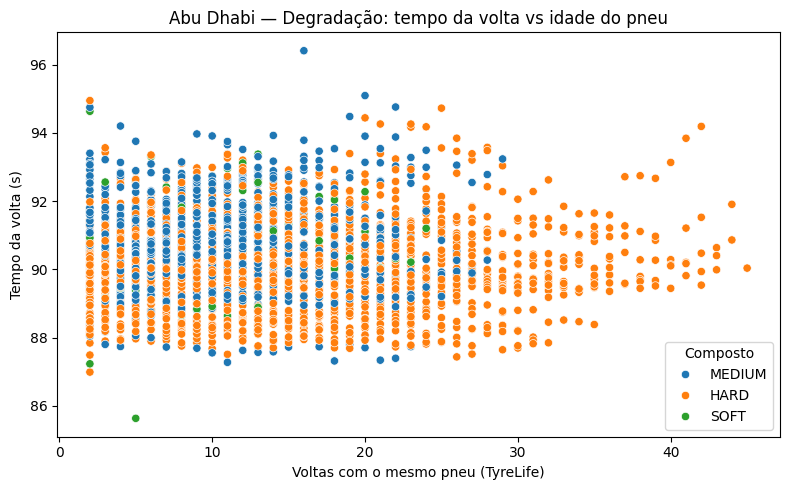

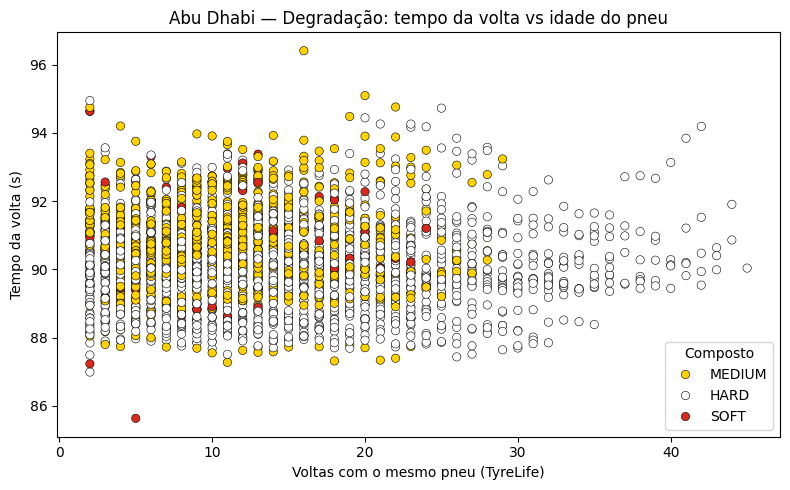

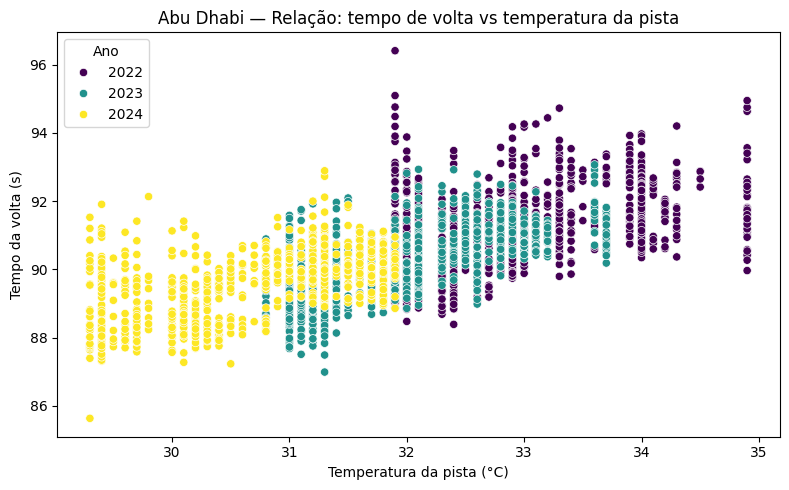


=== Australia ===


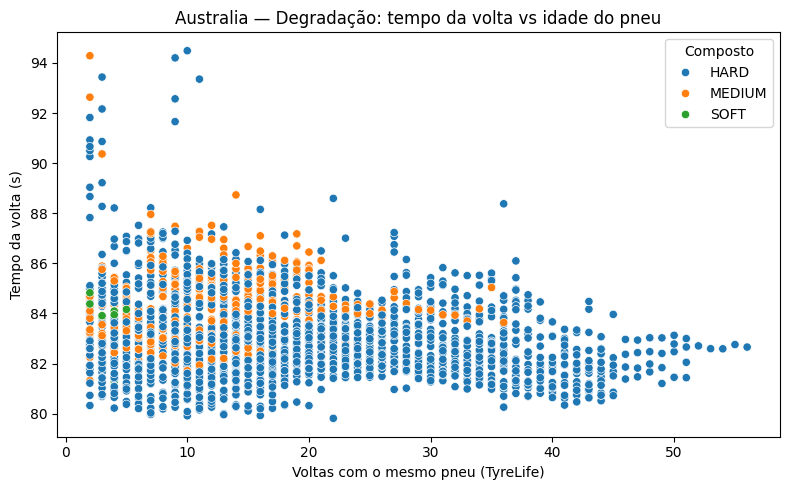

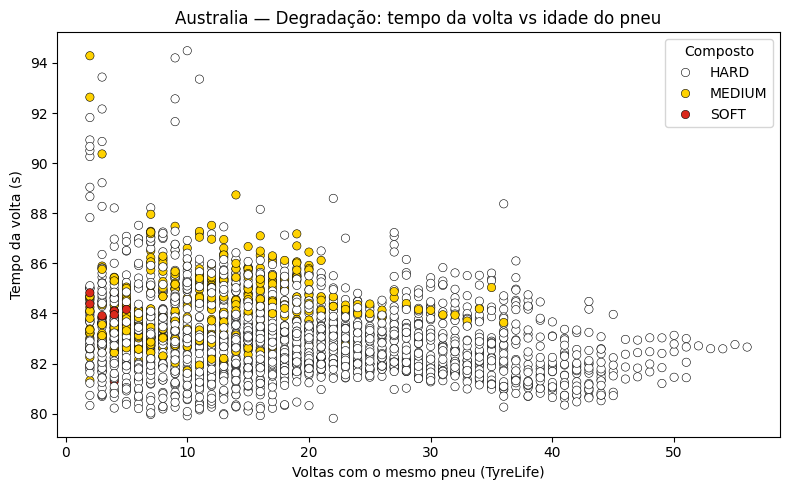

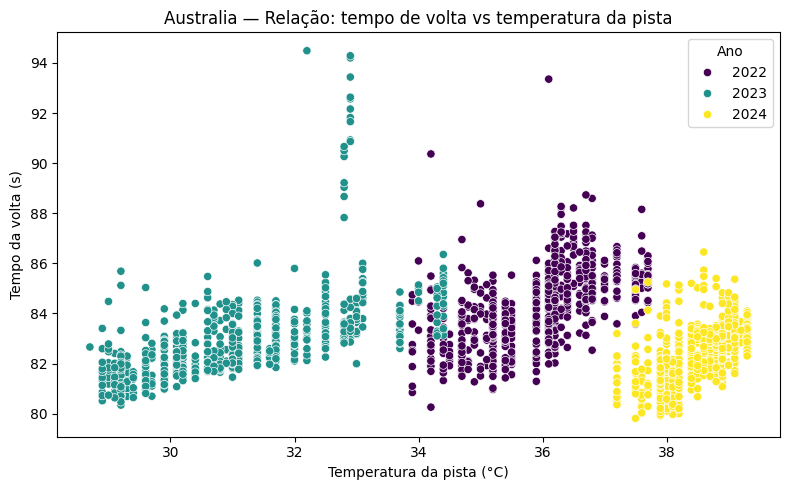


=== Bahrein ===


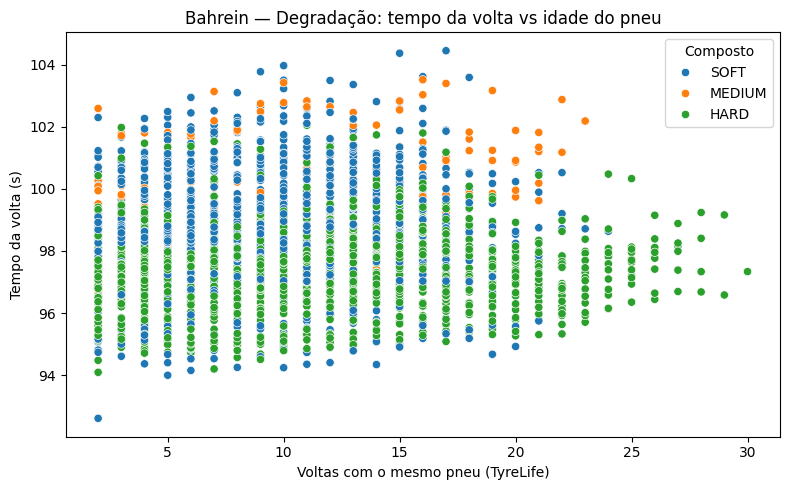

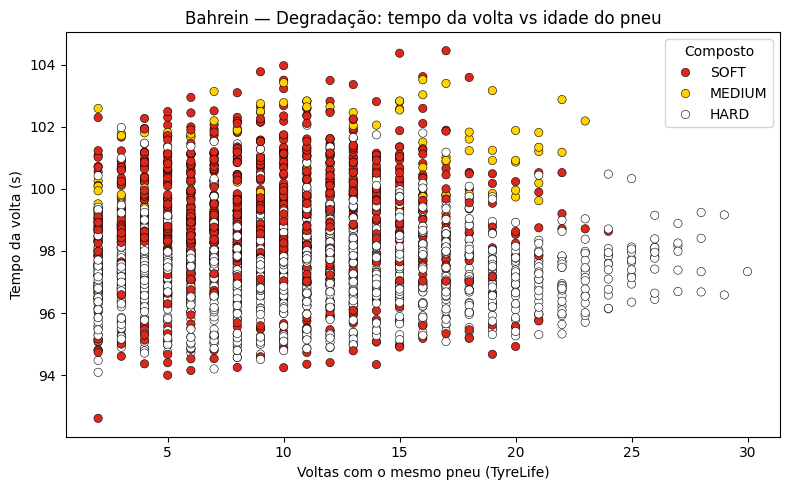

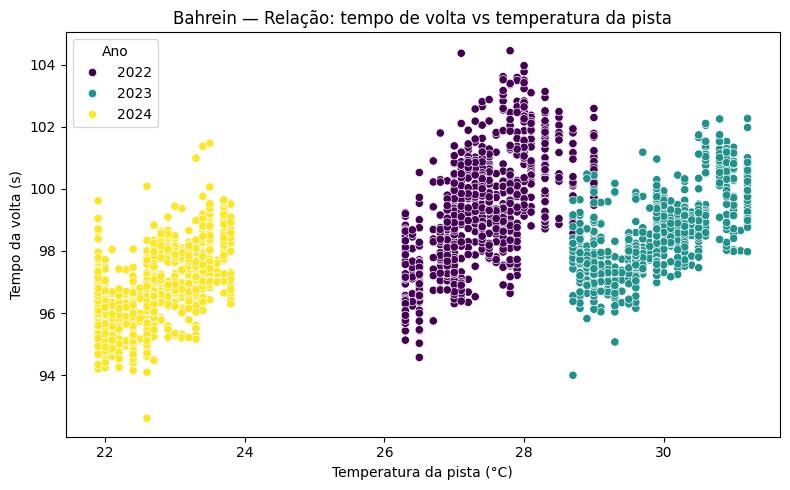


=== Baku ===


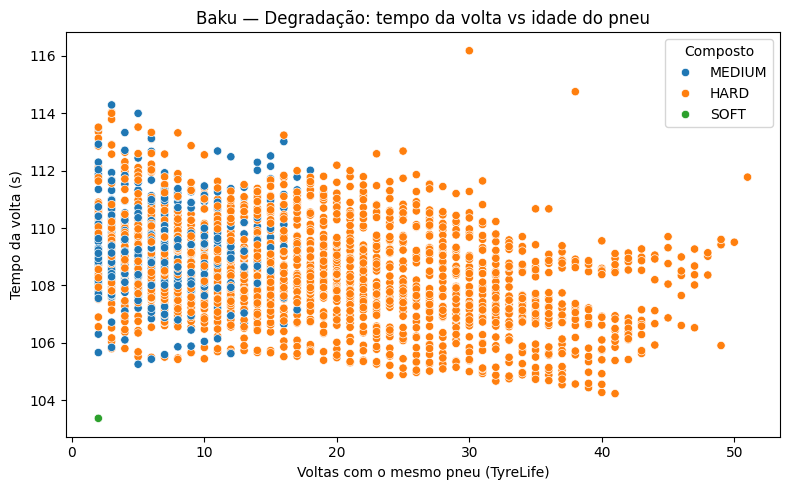

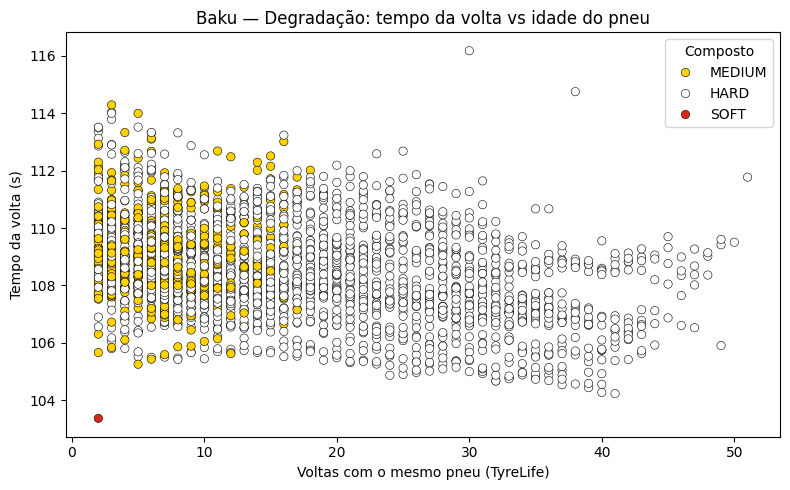

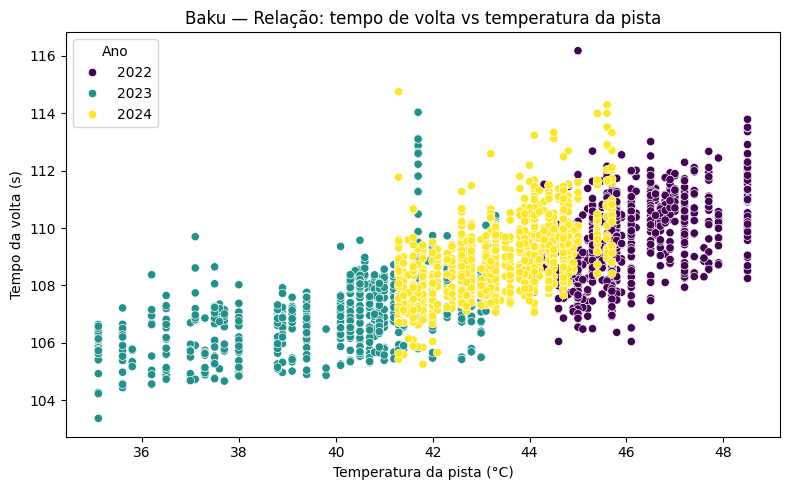


=== Brasil ===


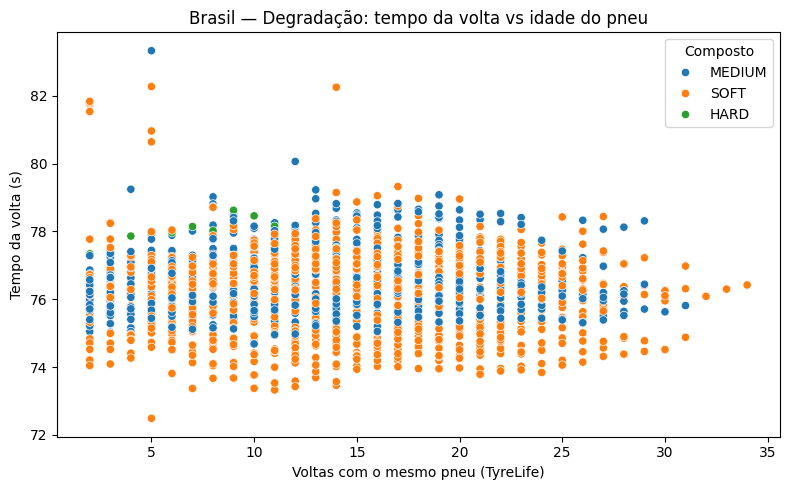

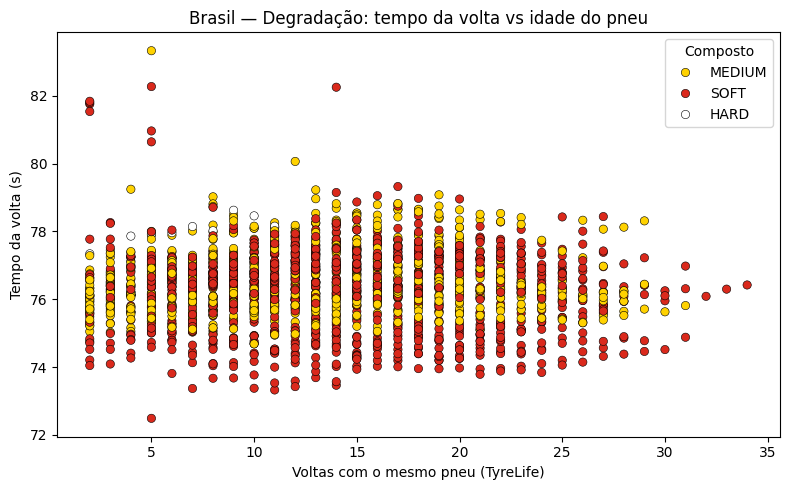

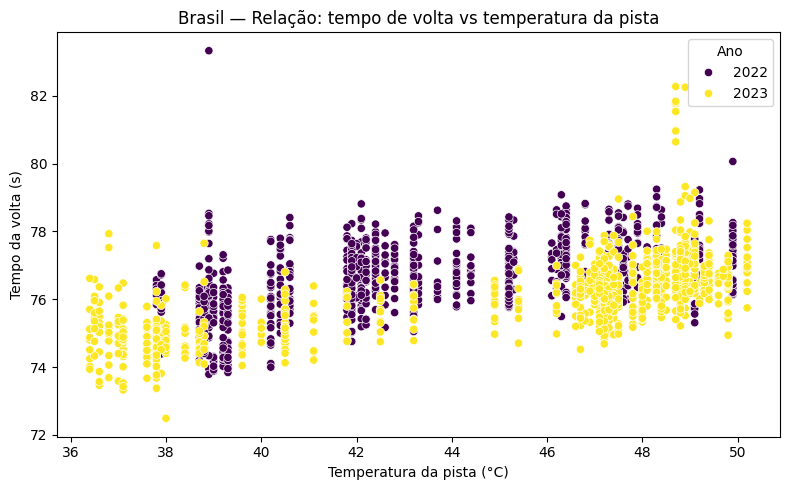


=== Bélgica ===


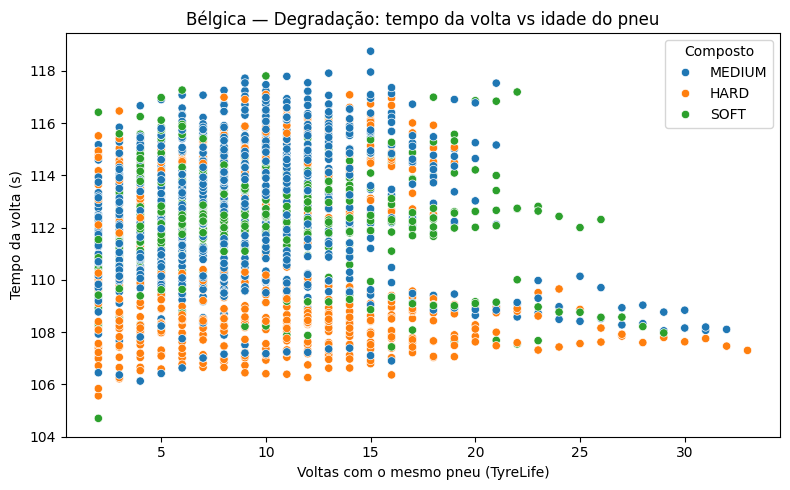

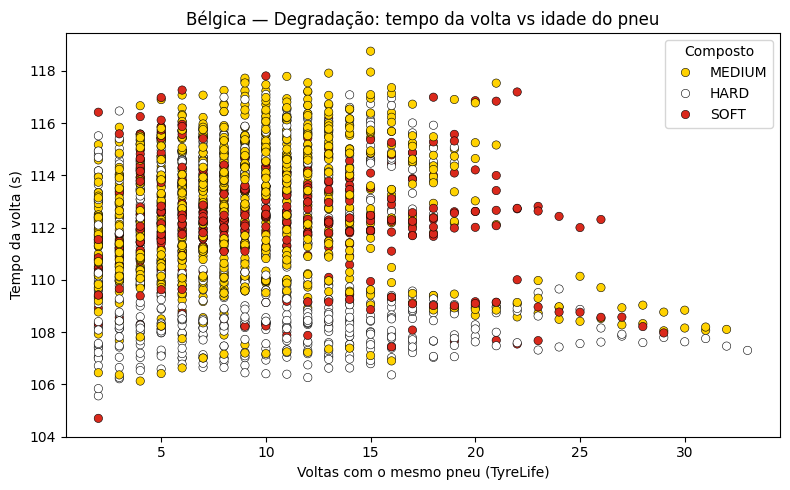

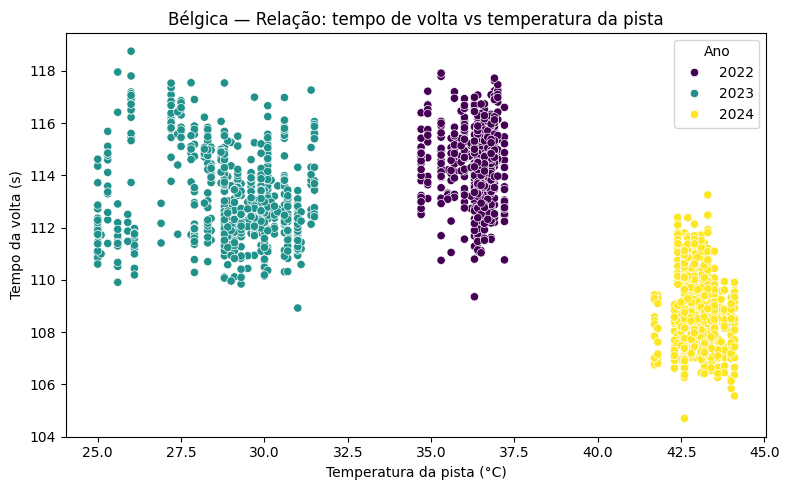


=== COTA ===


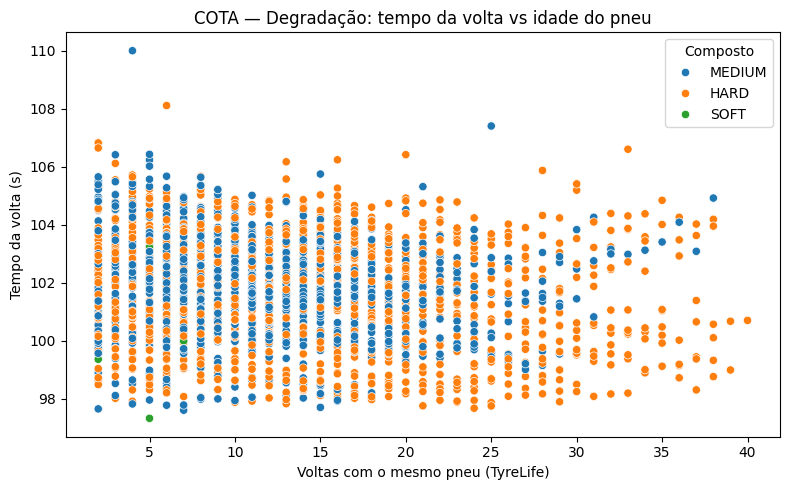

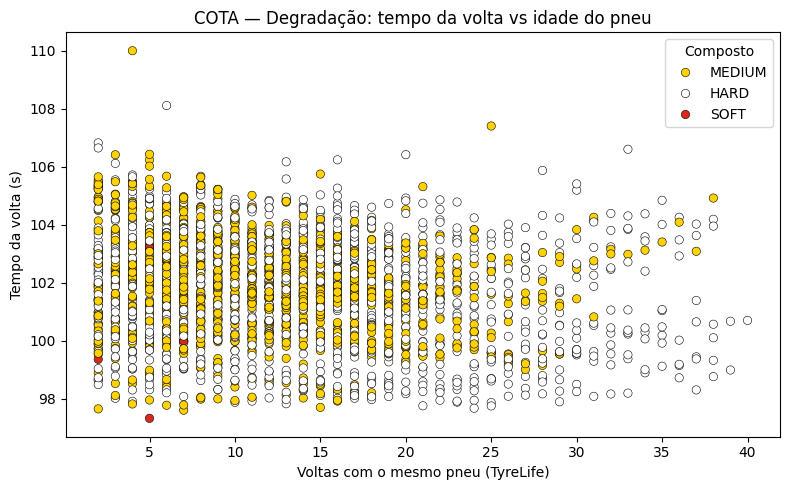

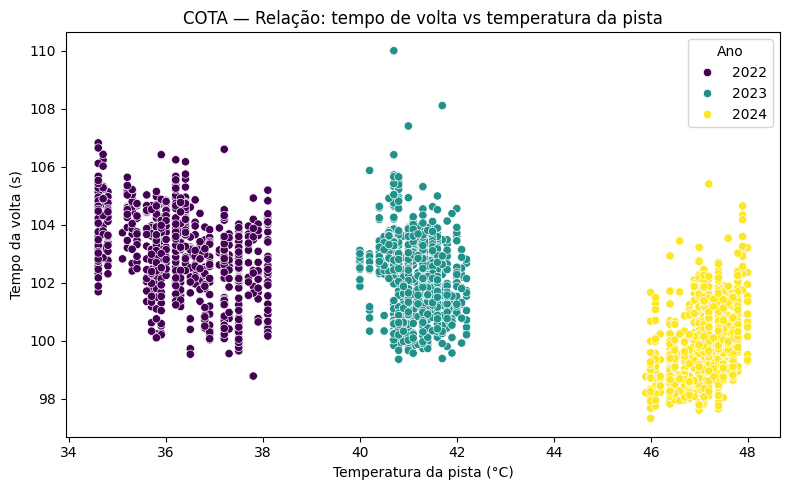


=== Hungria ===


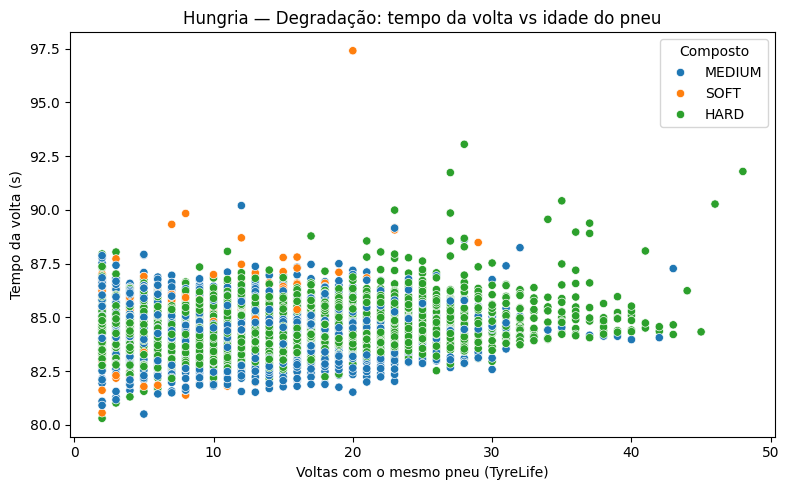

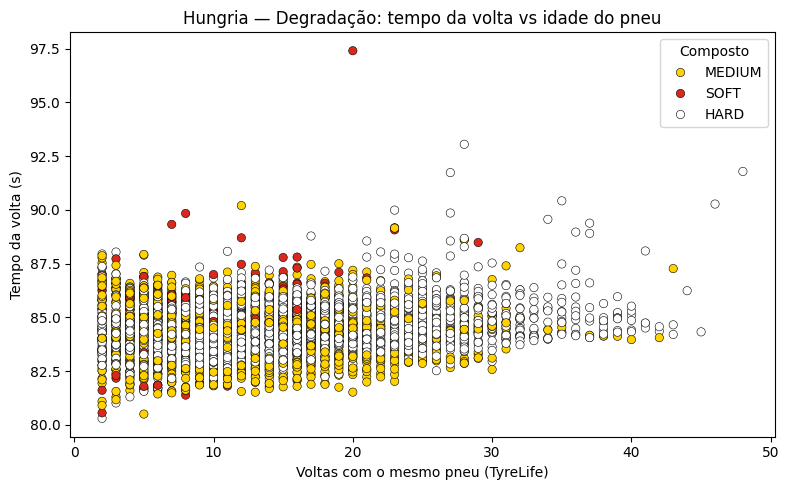

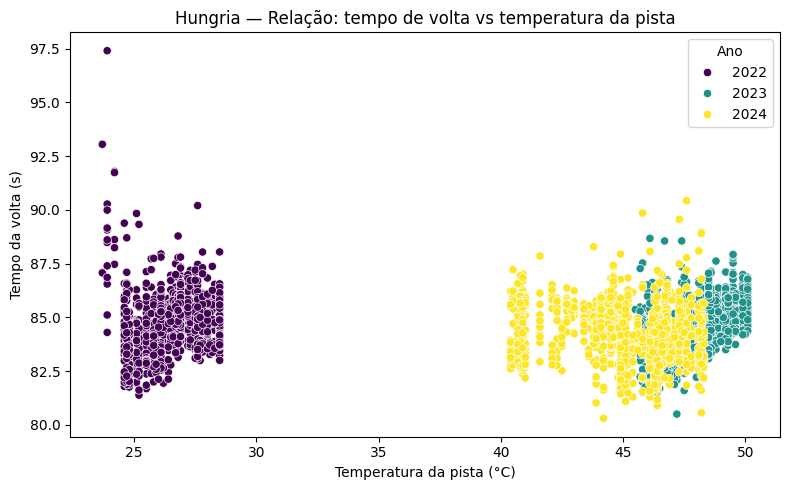


=== Jeddah ===


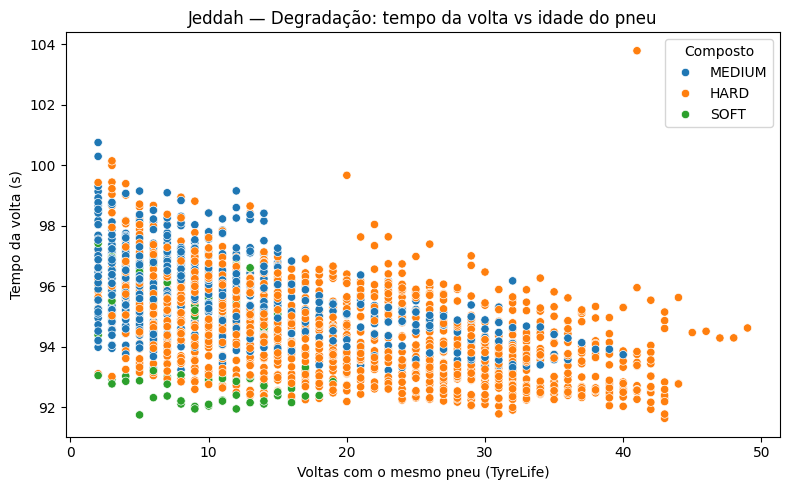

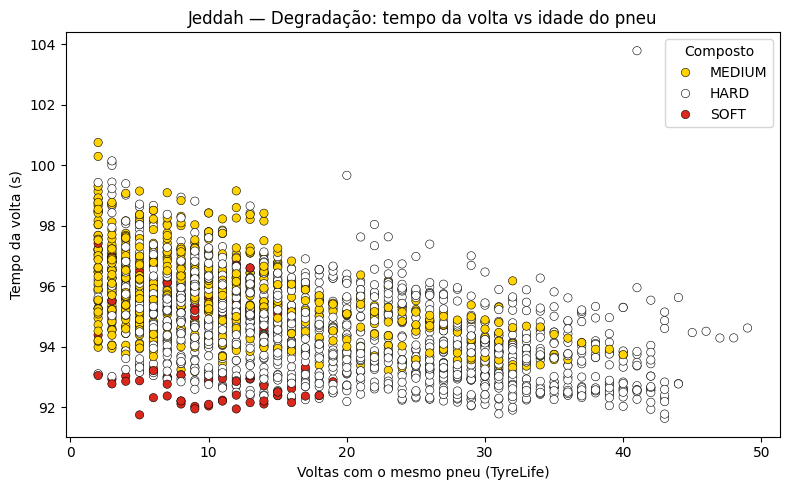

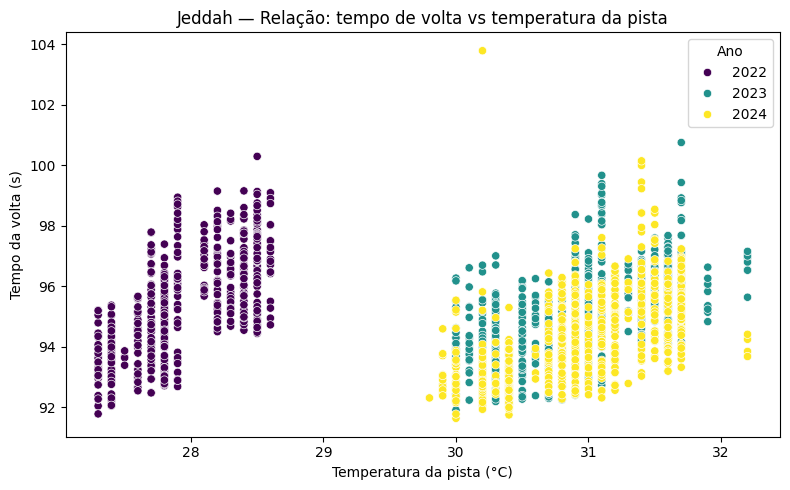


=== Mexico ===


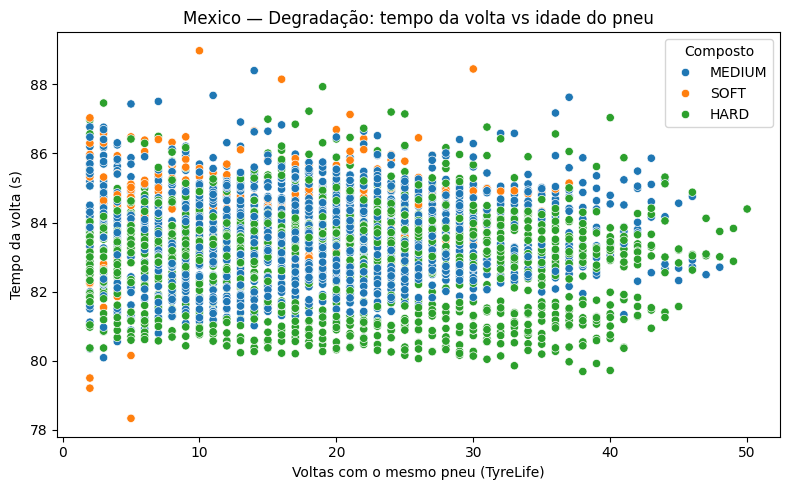

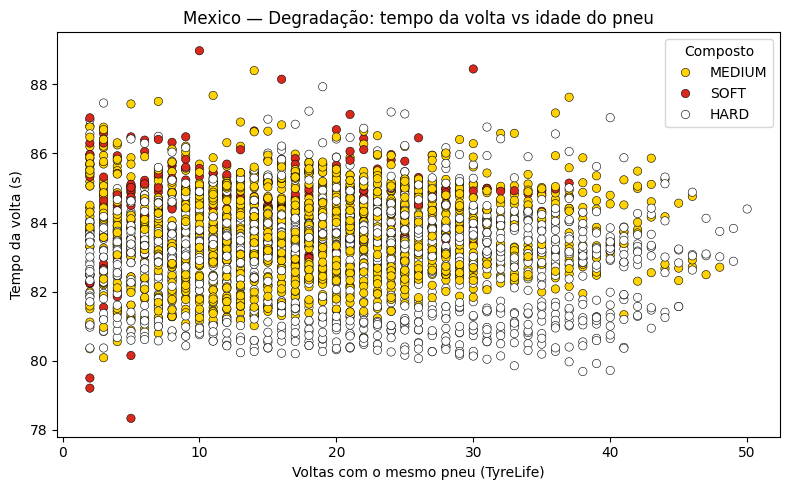

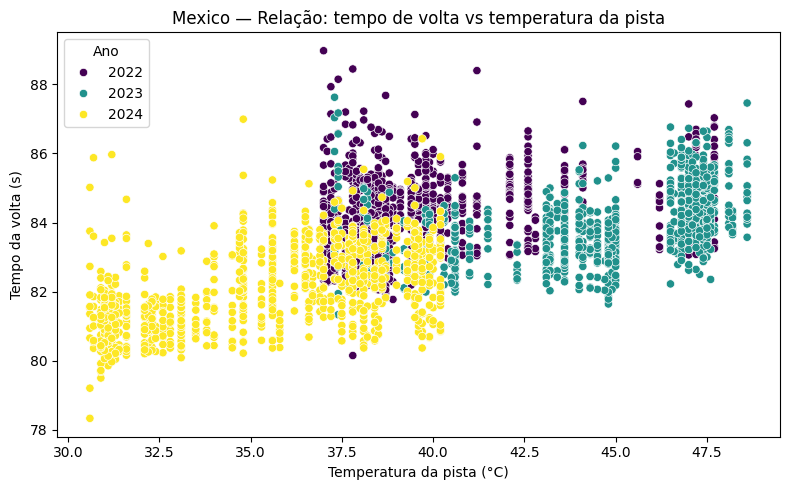


=== Miami ===


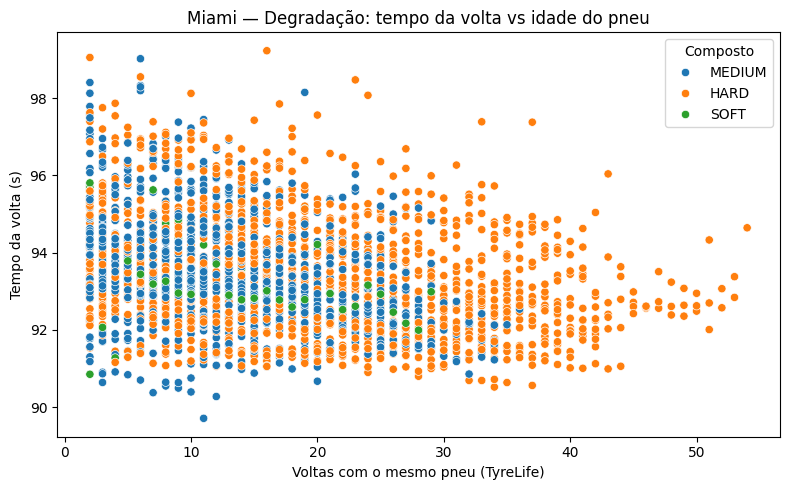

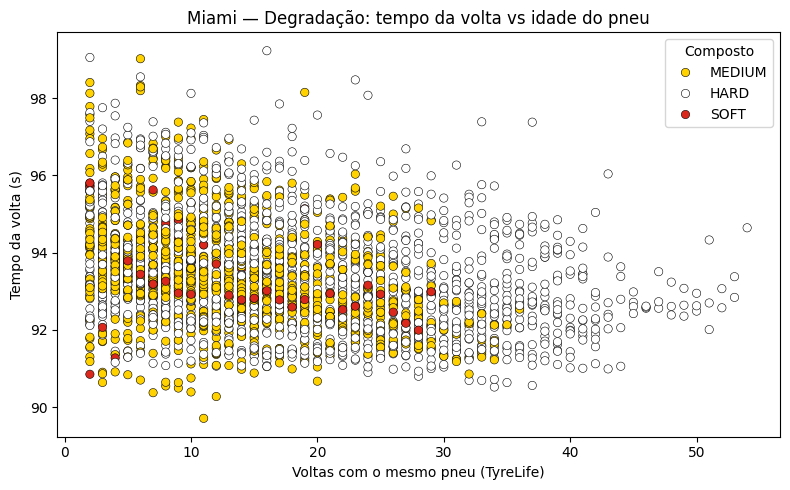

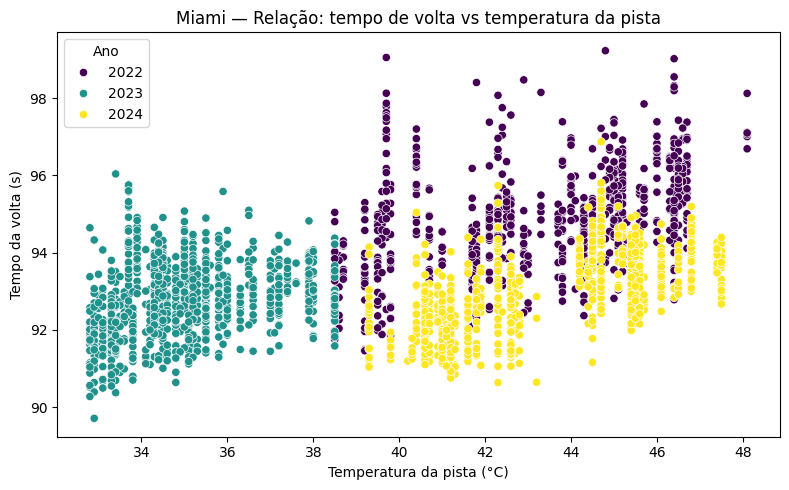


=== Monza ===


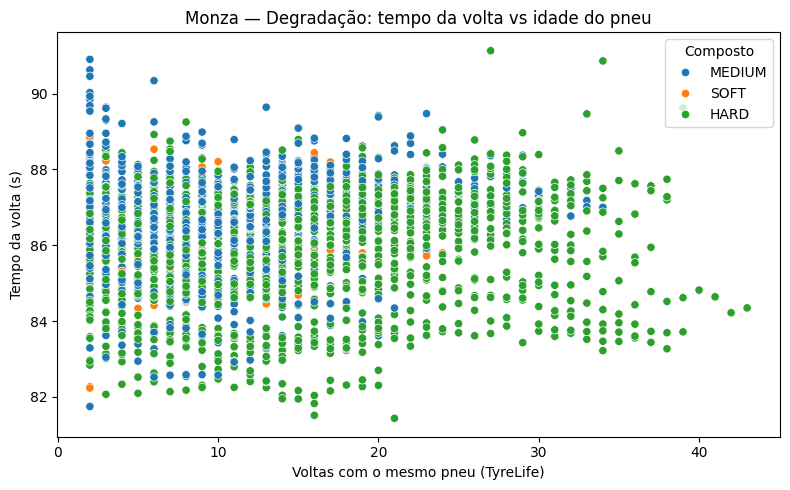

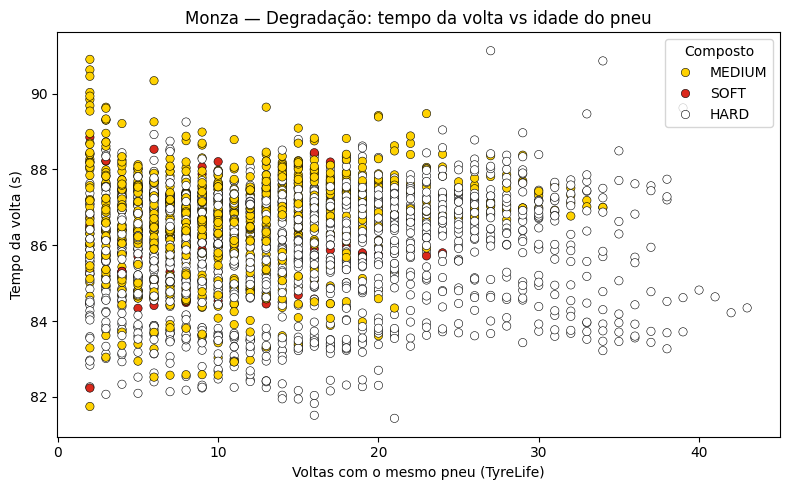

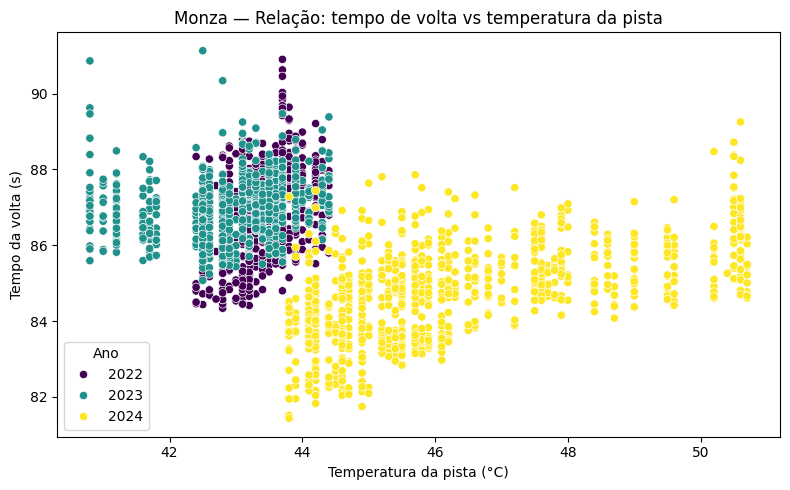


=== Mônaco ===


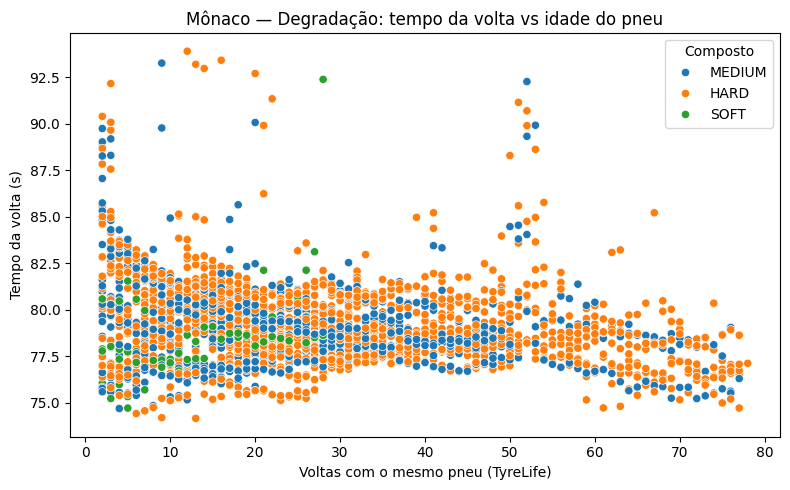

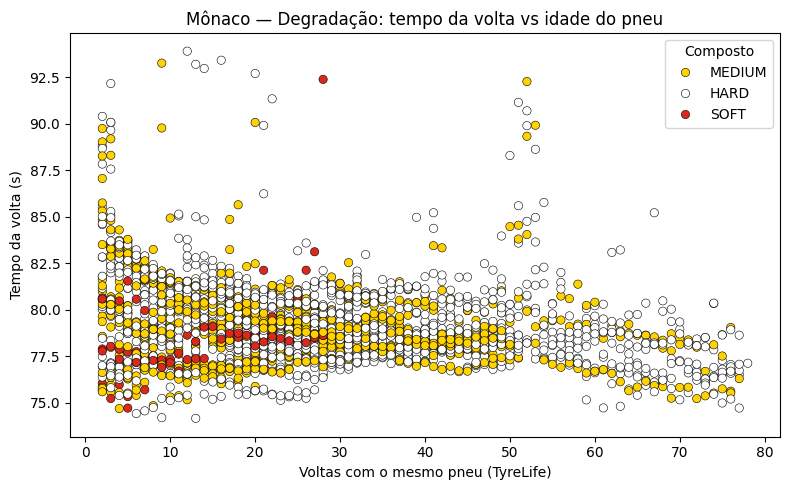

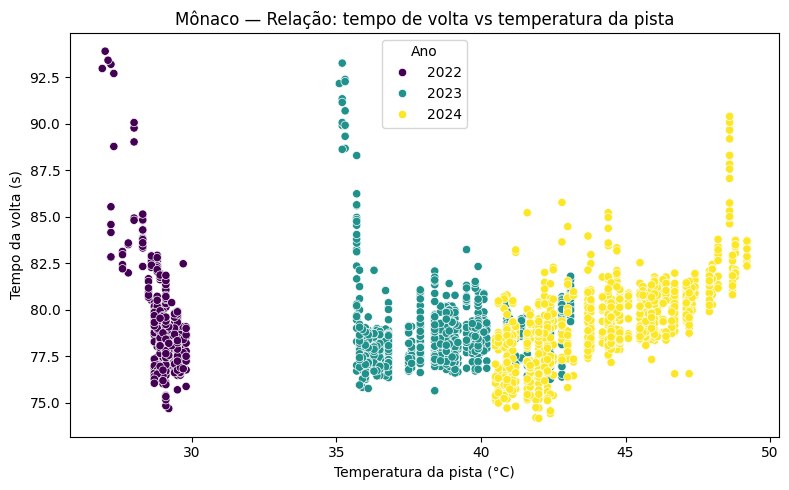


=== Silverstone ===


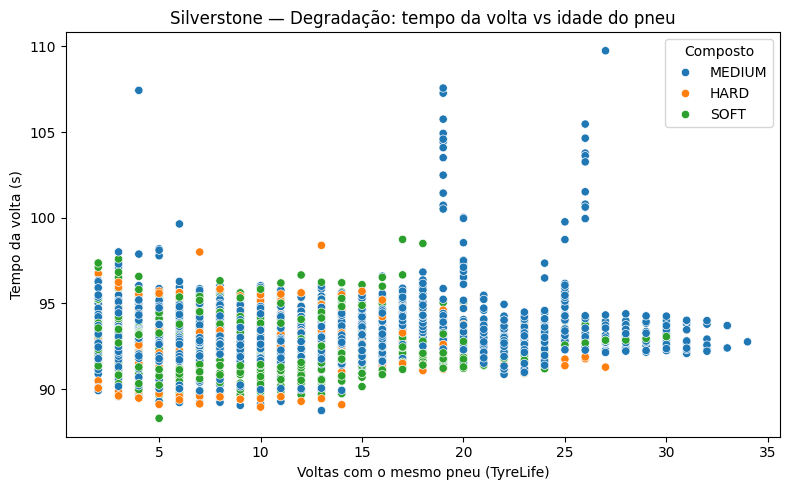

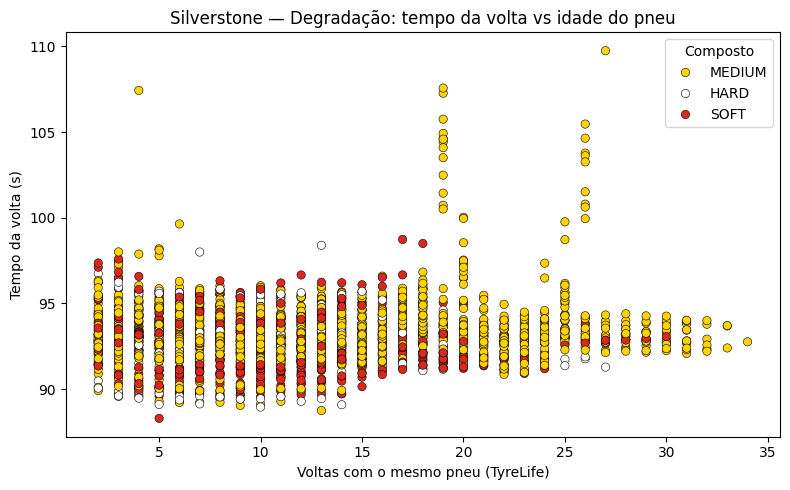

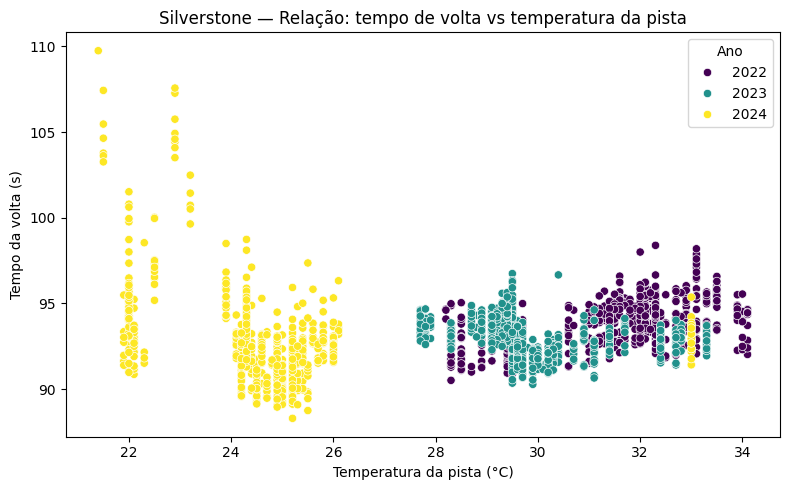


=== Singapura ===


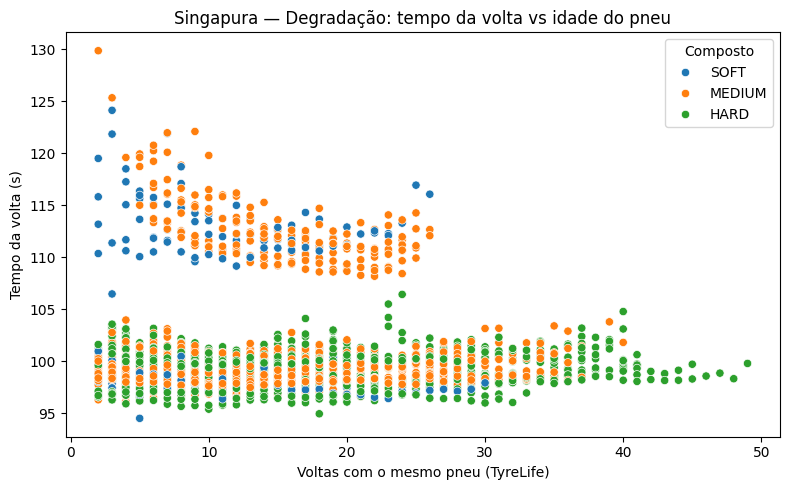

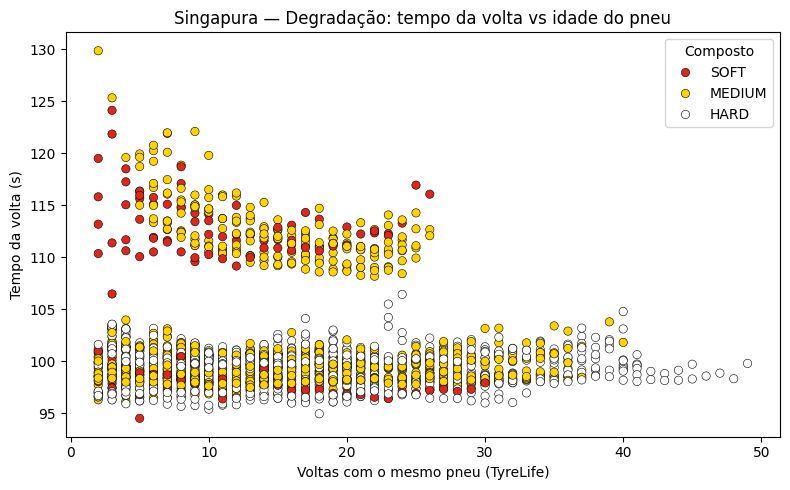

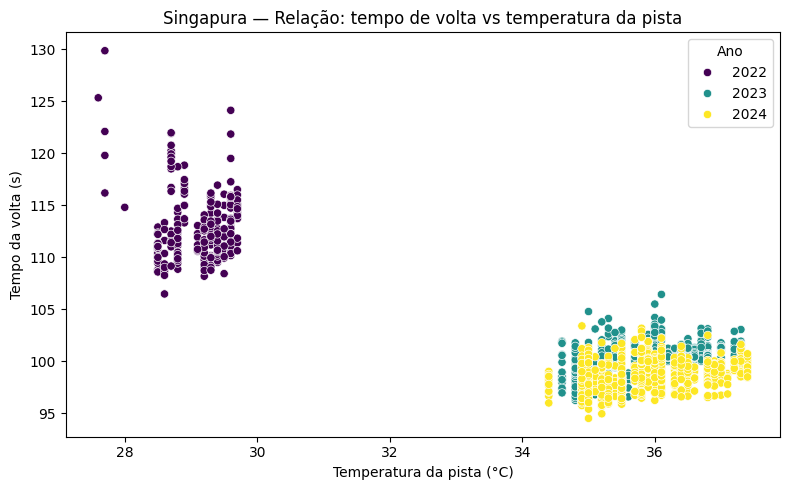


=== Suzuka ===


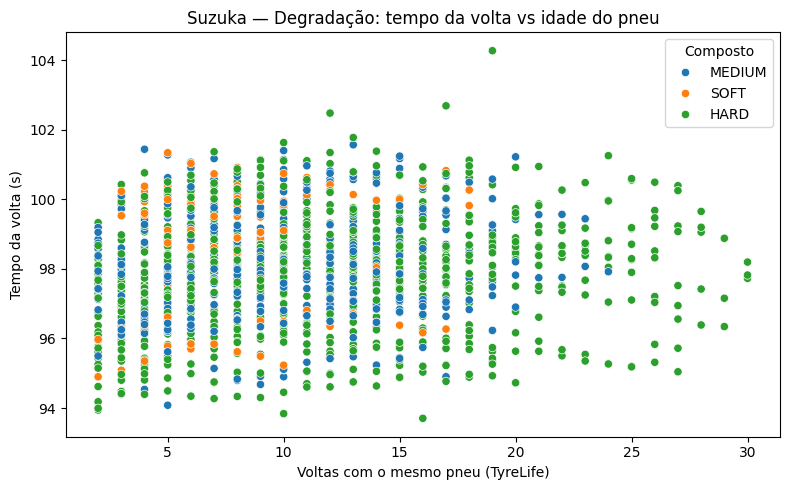

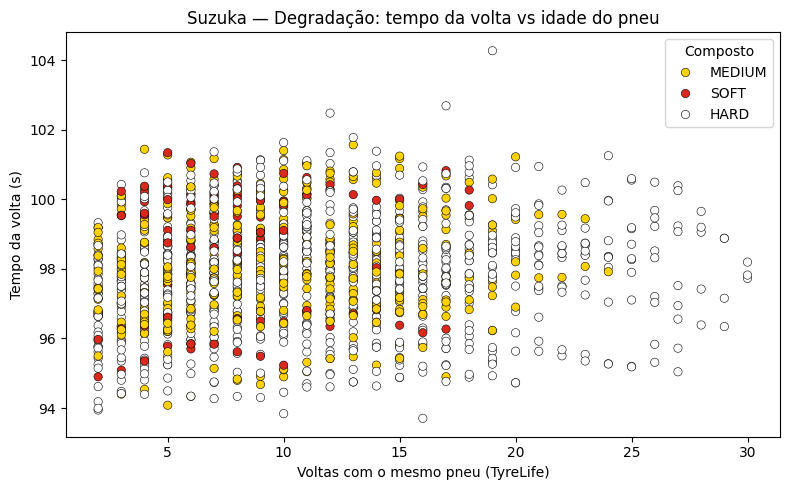

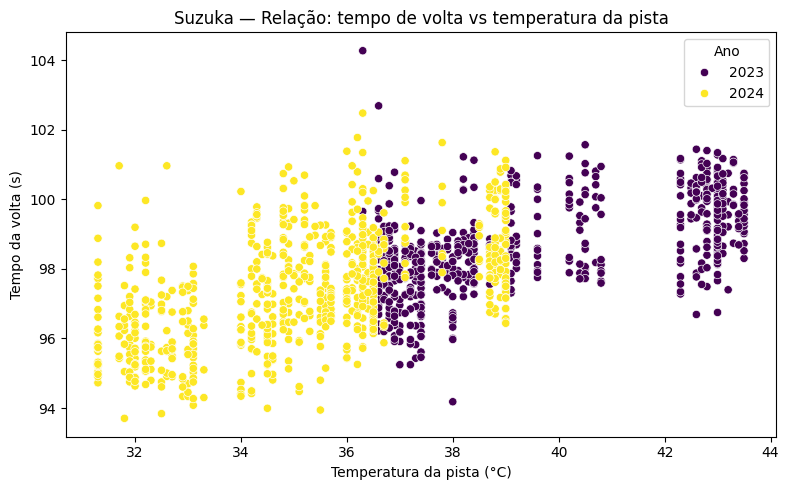

In [30]:
# === CÉLULA: Gráficos por circuito ===
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Mapeamento de cores (Pirelli) ----
# Soft (vermelho), Medium (amarelo), Hard (branco), Inter (verde), Wet (azul)
F1_COMPOUND_COLORS = {
    "SOFT": "#DA291C",         # vermelho Pirelli
    "MEDIUM": "#FFD200",       # amarelo Pirelli
    "HARD": "#FFFFFF",         # branco
    "INTERMEDIATE": "#43B02A", # verde Pirelli
    "INTER": "#43B02A",
    "WET": "#00A3E0",          # azul Pirelli
    "FULL WET": "#00A3E0",
}

# Cores associadas a letras curtas
SHORT_MAP = {
    "S": "SOFT",
    "M": "MEDIUM",
    "H": "HARD",
    "I": "INTERMEDIATE",
    "W": "WET",
}

# Caso venham compostos por faixa (C1..C5): ajuste típico
# (C5/C4 ~ Soft, C3 ~ Medium, C2/C1 ~ Hard; ajuste se quiser outra convenção)
def normalize_compound(name: str) -> str:
    if not isinstance(name, str):
        return "UNKNOWN"
    n = name.strip().upper()

    # Mapas curtos
    if n in SHORT_MAP:
        return SHORT_MAP[n]

    # Inter/Wet variações
    if "INTER" in n:
        return "INTERMEDIATE"
    if "WET" in n:
        return "WET"

    # Faixas C1..C5
    if n.startswith("C") and len(n) <= 3 and n[1:].isdigit():
        c = int(n[1:])
        if c in (5, 4):     # C5/C4 = Soft
            return "SOFT"
        elif c == 3:        # C3 = Medium
            return "MEDIUM"
        elif c in (2, 1, 0):# C2/C1/C0 = Hard
            return "HARD"

    # Padrões já escritos por extenso
    if n in F1_COMPOUND_COLORS:
        return n

    return "UNKNOWN"

def compound_color(name: str) -> str:
    comp = normalize_compound(name)
    return F1_COMPOUND_COLORS.get(comp, "#7F7F7F")  # cinza para desconhecidos


# Garante que temos Circuito, TyreLife, LapTimeSec, Compound, TrackTemp e Year
if "Circuito" in df.columns:
    circuitos = sorted(df["Circuito"].dropna().unique())
    print(f"Gerando gráficos para {len(circuitos)} circuitos...")

    for circuito in circuitos:
        subset = df[df["Circuito"] == circuito]
        print(f"\n=== {circuito} ===")

        # ----- Gráfico 1: Degradação - tempo da volta vs idade do pneu -----
        if {"TyreLife","LapTimeSec","Compound"} <= set(subset.columns):
            plt.figure(figsize=(8,5))
            sns.scatterplot(data=subset, x="TyreLife", y="LapTimeSec", hue="Compound")
            plt.title(f"{circuito} — Degradação: tempo da volta vs idade do pneu")
            plt.xlabel("Voltas com o mesmo pneu (TyreLife)")
            plt.ylabel("Tempo da volta (s)")
            plt.legend(title="Composto")
            plt.tight_layout()
            plt.show()


        # Versão aprimorada do gráfico 1 com cores Pirelli
        if {"TyreLife","LapTimeSec","Compound"} <= set(subset.columns):
            # Cria paleta apenas para os compostos presentes
            unique_compounds = subset["Compound"].dropna().unique().tolist()
            palette = {c: compound_color(c) for c in unique_compounds}

            plt.figure(figsize=(8,5))

            # Se tiver voltas com HARD (branco), borda preta ajuda a enxergar
            edgecol = "black" if any(normalize_compound(c) == "HARD" for c in unique_compounds) else None

            sns.scatterplot(
                data=subset,
                x="TyreLife",
                y="LapTimeSec",
                hue="Compound",
                palette=palette,
                edgecolor=edgecol,
                linewidth=0.4
            )

            plt.title(f"{circuito} — Degradação: tempo da volta vs idade do pneu")
            plt.xlabel("Voltas com o mesmo pneu (TyreLife)")
            plt.ylabel("Tempo da volta (s)")
            plt.legend(title="Composto", loc="best")
            plt.tight_layout()
            plt.show()

        # ----- Gráfico 2: Relação tempo vs temperatura da pista -----
        if {"TrackTemp","LapTimeSec","Year"} <= set(subset.columns) and subset["TrackTemp"].notna().any():
            plt.figure(figsize=(8,5))
            sns.scatterplot(data=subset, x="TrackTemp", y="LapTimeSec", hue="Year", palette="viridis")
            plt.title(f"{circuito} — Relação: tempo de volta vs temperatura da pista")
            plt.xlabel("Temperatura da pista (°C)")
            plt.ylabel("Tempo da volta (s)")
            plt.legend(title="Ano")
            plt.tight_layout()
            plt.show()

else:
    print("A coluna 'Circuito' não está no DataFrame; certifique-se de ter essa informação antes de rodar esta célula.")
